## 1.load and process data

In [1]:
import pandas as pd
# Load the training data
train_df = pd.read_csv('cleaned_training.csv')
print(train_df.head())  

# Load the test data
test_df = pd.read_csv('cleaned_testing.csv')
print(test_df.head())  

# Load the validation data
val_df = pd.read_csv('cleaned_validation.csv')
print(val_df.head())


   Label                                               text
0      0   Send forth all legions. Do not stop the attac...
1      0                                What of the Wizard?
2      0                                 I shall break him.
3      0                        Where are Theoden's riders?
4      0                            Will Rohan's army come?
   Label                                               text
0      0                                   We need to talk.
1      0                                              Sure.
2      1   I'm on to you. You're a faker. You aren't dying.
3      1                                              What?
4      1   Okay, in the Sylvia Plath philosophy way, we'...
   Label                                               text
0      0                           How many people go here?
1      0                 Couple thousand. Most of them evil
2      0   We've got your basic beautiful people. Unless...
3      0                            Thos

In [5]:
# Extract features and labels from the training set
X_train = train_df['text']
y_train = train_df['Label']

# Extract features and labels from the test set
X_test = test_df['text']
y_test = test_df['Label']

# Extract features and labels from the validation set
X_val = val_df['text']
y_val = val_df['Label']


len(X_train), len(y_train), len(X_test), len(y_test), len(X_val), len(y_val)  # 查看数据集的大小


(314, 314, 101, 101, 105, 105)

In [12]:
from collections import Counter

def majority_class_baseline(y_train):
    """
    计算训练集的多数类基线（Majority Class Baseline）。
    
    参数:
    y_train (pd.Series or list): 训练集的标签列表。
    
    返回:
    float: 多数类的比例（即基线准确率）。
    """
    label_counts = Counter(y_train)  # 统计每个类别的样本数
    majority_class_count = max(label_counts.values())  # 找到最多的类别样本数
    total_samples = len(y_train)  # 训练集总样本数
    baseline_accuracy = majority_class_count / total_samples  # 计算基线准确率
    
    return baseline_accuracy

# 提取训练集的特征和标签
X_train, y_train = train_df['text'], train_df['Label']

# 提取测试集的特征和标签
X_test, y_test = test_df['text'], test_df['Label']

# 提取验证集的特征和标签
X_val, y_val = val_df['text'], val_df['Label']

# 计算 Majority Class Baseline
baseline = majority_class_baseline(y_train)
print(f"Majority Class Baseline Accuracy: {baseline:.2%}")

# 查看数据集大小
len(X_train), len(y_train), len(X_test), len(y_test), len(X_val), len(y_val)


Majority Class Baseline Accuracy: 65.29%


(314, 314, 101, 101, 105, 105)

/tmp/ipykernel_1576/3691020216.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_counts.index, y=train_counts.values, palette='Blues')
/tmp/ipykernel_1576/3691020216.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=val_counts.index, y=val_counts.values, palette='Greens')
/tmp/ipykernel_1576/3691020216.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=test_counts.index, y=test_counts.values, palette='Reds')


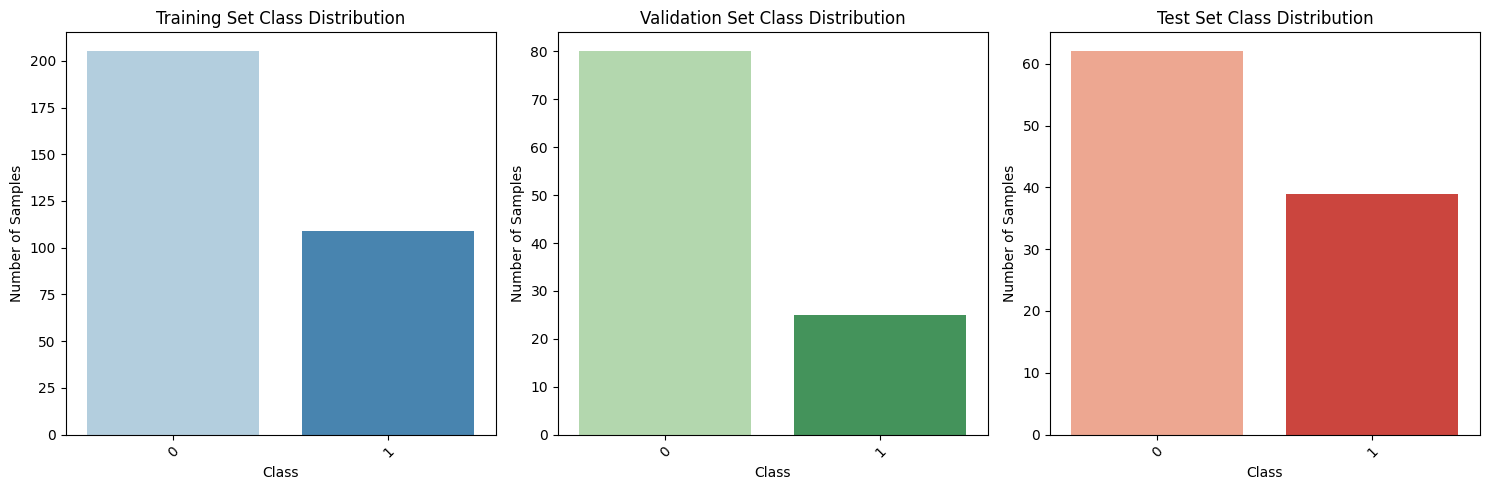

Training Set Class Distribution:
Label
0    205
1    109
Name: count, dtype: int64

Validation Set Class Distribution:
Label
0    80
1    25
Name: count, dtype: int64

Test Set Class Distribution:
Label
0    62
1    39
Name: count, dtype: int64


In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
train_df = pd.read_csv('cleaned_training.csv')
val_df = pd.read_csv('cleaned_validation.csv')
test_df = pd.read_csv('cleaned_testing.csv')

# Set figure size
plt.figure(figsize=(15, 5))

# Training set distribution
plt.subplot(1, 3, 1)
train_counts = train_df['Label'].value_counts()
sns.barplot(x=train_counts.index, y=train_counts.values, palette='Blues')
plt.title('Training Set Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)

# Validation set distribution
plt.subplot(1, 3, 2)
val_counts = val_df['Label'].value_counts()
sns.barplot(x=val_counts.index, y=val_counts.values, palette='Greens')
plt.title('Validation Set Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)

# Test set distribution
plt.subplot(1, 3, 3)
test_counts = test_df['Label'].value_counts()
sns.barplot(x=test_counts.index, y=test_counts.values, palette='Reds')
plt.title('Test Set Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Print specific values
print("Training Set Class Distribution:")
print(train_counts)
print("\nValidation Set Class Distribution:")
print(val_counts)
print("\nTest Set Class Distribution:")
print(test_counts)



# 2.The majority class baseline

In [14]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load data
train_df = pd.read_csv('cleaned_training.csv')
val_df = pd.read_csv('cleaned_validation.csv')  # 加载开发集
test_df = pd.read_csv('cleaned_testing.csv')

# Extract labels
y_train = train_df['Label']
y_val = val_df['Label']
y_test = test_df['Label']

# Calculate the majority class in the training set
majority_class = y_train.mode()[0]  # 训练集中的多数类

# Predict all validation and test samples as the majority class
y_pred_val = [majority_class] * len(y_val)   # 开发集预测
y_pred_test = [majority_class] * len(y_test) # 测试集预测

# Evaluate on validation set
val_accuracy = accuracy_score(y_val, y_pred_val)
print(f'Majority Class Baseline Accuracy on Validation Set: {val_accuracy:.2%}')
print('Classification Report (Validation Set):\n', 
      classification_report(y_val, y_pred_val, zero_division=0))
print('Confusion Matrix (Validation Set):\n', confusion_matrix(y_val, y_pred_val))

# Evaluate on test set
test_accuracy = accuracy_score(y_test, y_pred_test)
print(f'\nMajority Class Baseline Accuracy on Test Set: {test_accuracy:.2%}')
print('Classification Report (Test Set):\n', 
      classification_report(y_test, y_pred_test, zero_division=0))
print('Confusion Matrix (Test Set):\n', confusion_matrix(y_test, y_pred_test))


Majority Class Baseline Accuracy on Validation Set: 76.19%
Classification Report (Validation Set):
               precision    recall  f1-score   support

           0       0.76      1.00      0.86        80
           1       0.00      0.00      0.00        25

    accuracy                           0.76       105
   macro avg       0.38      0.50      0.43       105
weighted avg       0.58      0.76      0.66       105

Confusion Matrix (Validation Set):
 [[80  0]
 [25  0]]

Majority Class Baseline Accuracy on Test Set: 61.39%
Classification Report (Test Set):
               precision    recall  f1-score   support

           0       0.61      1.00      0.76        62
           1       0.00      0.00      0.00        39

    accuracy                           0.61       101
   macro avg       0.31      0.50      0.38       101
weighted avg       0.38      0.61      0.47       101

Confusion Matrix (Test Set):
 [[62  0]
 [39  0]]


✅ 用训练集计算 Majority Class
✅ 在验证集和测试集上评估 Majority Baseline
✅ 比较模型效果时，用验证集的 Baseline

The majority class baseline is often used to set the lowest possible performance benchmark. If a machine learning model does not outperform this baseline, then it suggests that the model is not capturing meaningful patterns in the data. In practical applications, we would want to go beyond the majority class baseline and design models that can correctly classify both the majority and minority classes.

# 3.SVM


Validation Set Metrics:
Validation Accuracy: 0.7523809523809524
Validation F1 Score: 0.7523809523809524
Validation Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.84      0.84        80
           1       0.48      0.48      0.48        25

    accuracy                           0.75       105
   macro avg       0.66      0.66      0.66       105
weighted avg       0.75      0.75      0.75       105


Test Set Metrics:
Test Accuracy: 0.5841584158415841
Test F1 Score: 0.5647005877058294
Test Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.76      0.69        62
           1       0.44      0.31      0.36        39

    accuracy                           0.58       101
   macro avg       0.54      0.53      0.53       101
weighted avg       0.56      0.58      0.56       101



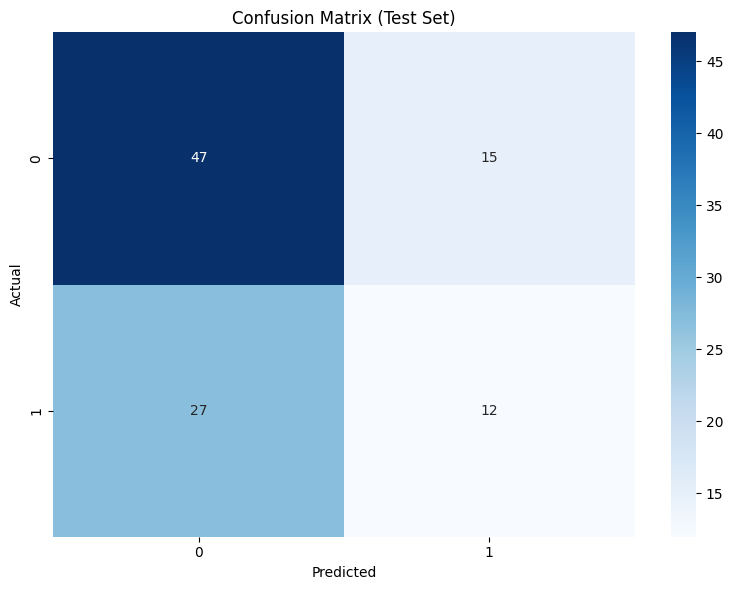

In [36]:
import pandas as pd
import numpy as np
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import re

def basic_cleaning(text):
    """
    Perform basic text cleaning:
    - Remove extra whitespace
    - Convert to lowercase
    """
    text = text.strip()
    text = text.lower()
    return text

def train_and_evaluate_model(train_df, val_df, test_df):
    """
    Train a LinearSVC model and evaluate its performance using train, validation, and test sets
    
    Returns:
        tuple: Trained pipeline, predictions, and evaluation metrics
    """
    # Clean text data
    train_df['text'] = train_df['text'].apply(basic_cleaning)
    val_df['text'] = val_df['text'].apply(basic_cleaning)
    test_df['text'] = test_df['text'].apply(basic_cleaning)
    
    # Extract features and labels
    X_train = train_df['text']
    y_train = train_df['Label']
    X_val = val_df['text']
    y_val = val_df['Label']
    X_test = test_df['text']
    y_test = test_df['Label']
    
    # Create a model pipeline
    pipeline = make_pipeline(
        TfidfVectorizer(),  # TF-IDF vectorization
        LinearSVC()  # Linear Support Vector Classifier
    )
    
    # Train the model on training data
    pipeline.fit(X_train, y_train)
    
    # Evaluate on validation set
    val_pred = pipeline.predict(X_val)
    val_accuracy = accuracy_score(y_val, val_pred)
    val_f1 = f1_score(y_val, val_pred, average='weighted')
    
    print('Validation Set Metrics:')
    print('Validation Accuracy:', val_accuracy)
    print('Validation F1 Score:', val_f1)
    print('Validation Classification Report:\n', classification_report(y_val, val_pred))
    
    # Evaluate on test set
    y_pred = pipeline.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred, average='weighted')
    
    print('\nTest Set Metrics:')
    print('Test Accuracy:', test_accuracy)
    print('Test F1 Score:', test_f1)
    print('Test Classification Report:\n', classification_report(y_test, y_pred))
    
    # Visualize confusion matrix for test set
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=np.unique(y_test), 
                yticklabels=np.unique(y_test))
    plt.title('Confusion Matrix (Test Set)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()
    
    return pipeline, y_pred, {
        'val_accuracy': val_accuracy,
        'val_f1_score': val_f1,
        'test_accuracy': test_accuracy,
        'test_f1_score': test_f1,
        'test_confusion_matrix': cm
    }

def main():
    # Load data
    train_df = pd.read_csv('cleaned_training.csv')
    val_df = pd.read_csv('cleaned_validation.csv')
    test_df = pd.read_csv('cleaned_testing.csv')
    
    # Train and evaluate the model
    model, predictions, metrics = train_and_evaluate_model(train_df, val_df, test_df)

if __name__ == "__main__":
    main()



## best

Best Parameters: {'linearsvc__C': 1, 'linearsvc__loss': 'squared_hinge', 'linearsvc__max_iter': 5000, 'tfidfvectorizer__max_features': 5000, 'tfidfvectorizer__ngram_range': (1, 2)}
Validation Set Metrics:
Validation Accuracy: 0.7238095238095238
Validation F1 Score: 0.7175365642928625
Validation Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.84      0.82        80
           1       0.41      0.36      0.38        25

    accuracy                           0.72       105
   macro avg       0.61      0.60      0.60       105
weighted avg       0.71      0.72      0.72       105


Test Set Metrics:
Test Accuracy: 0.6039603960396039
Test F1 Score: 0.5933307616475934
Test Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.74      0.70        62
           1       0.48      0.38      0.43        39

    accuracy                           0.60       101
   macro avg       

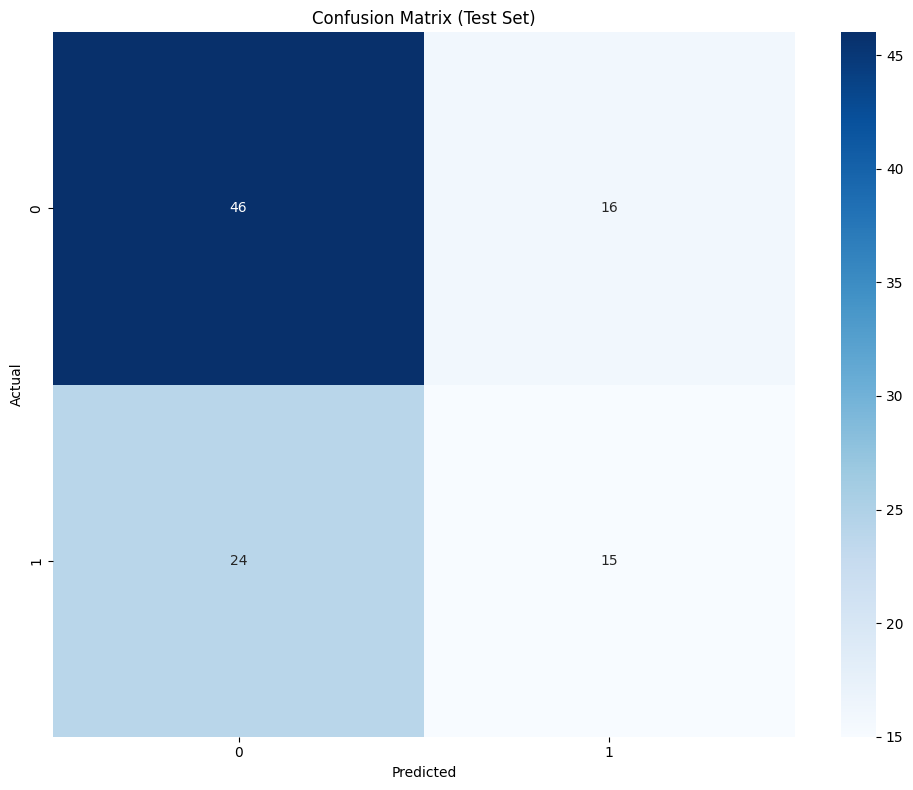

In [41]:
import pandas as pd
import numpy as np
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import re

def basic_cleaning(text):
    """
    Perform comprehensive text cleaning:
    - Remove extra whitespace
    - Convert to lowercase
    - Remove special characters and digits (optional)
    """
    # Remove special characters and digits (uncomment if needed)
    # text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    text = text.strip()
    text = text.lower()
    return text

def train_and_evaluate_model(train_df, val_df, test_df):
    """
    Train a LinearSVC model with hyperparameter tuning and comprehensive evaluation
    
    Returns:
        tuple: Trained pipeline, predictions, and evaluation metrics
    """
    # Clean text data
    train_df['text'] = train_df['text'].apply(basic_cleaning)
    val_df['text'] = val_df['text'].apply(basic_cleaning)
    test_df['text'] = test_df['text'].apply(basic_cleaning)
    
    # Encode labels
    le = LabelEncoder()
    train_df['Label'] = le.fit_transform(train_df['Label'])
    val_df['Label'] = le.transform(val_df['Label'])
    test_df['Label'] = le.transform(test_df['Label'])
    
    # Extract features and labels
    X_train = train_df['text']
    y_train = train_df['Label']
    X_val = val_df['text']
    y_val = val_df['Label']
    X_test = test_df['text']
    y_test = test_df['Label']
    
    # Define parameter grid for GridSearchCV
    pipeline = make_pipeline(
        TfidfVectorizer(),
        LinearSVC()
    )
    
    param_grid = {
        'tfidfvectorizer__max_features': [5000, 10000, None],
        'tfidfvectorizer__ngram_range': [(1, 1), (1, 2)],
        'linearsvc__C': [0.1, 1, 10],
        'linearsvc__loss': ['hinge', 'squared_hinge'],
        'linearsvc__max_iter': [5000]
    }
    
    # Perform Grid Search with Cross-Validation
    grid_search = GridSearchCV(
        pipeline, 
        param_grid, 
        cv=5, 
        scoring='f1_weighted', 
        n_jobs=-1  # Use all available cores
    )
    
    # Fit the grid search
    grid_search.fit(X_train, y_train)
    
    # Best model
    best_pipeline = grid_search.best_estimator_
    
    # Print best parameters
    print("Best Parameters:", grid_search.best_params_)
    
    # Validation set evaluation
    val_pred = best_pipeline.predict(X_val)
    val_accuracy = accuracy_score(y_val, val_pred)
    val_f1 = f1_score(y_val, val_pred, average='weighted')
    
    print('Validation Set Metrics:')
    print('Validation Accuracy:', val_accuracy)
    print('Validation F1 Score:', val_f1)
    print('Validation Classification Report:\n', classification_report(y_val, val_pred))
    
    # Test set evaluation
    y_pred = best_pipeline.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred, average='weighted')
    
    print('\nTest Set Metrics:')
    print('Test Accuracy:', test_accuracy)
    print('Test F1 Score:', test_f1)
    print('Test Classification Report:\n', classification_report(y_test, y_pred))
    
    # Visualize confusion matrix for test set
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues',
        xticklabels=le.classes_,
        yticklabels=le.classes_
    )
    plt.title('Confusion Matrix (Test Set)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()
    
    return best_pipeline, y_pred, {
        'best_params': grid_search.best_params_,
        'val_accuracy': val_accuracy,
        'val_f1_score': val_f1,
        'test_accuracy': test_accuracy,
        'test_f1_score': test_f1,
        'test_confusion_matrix': cm
    }

def main():
    # Load data
    train_df = pd.read_csv('cleaned_training.csv')
    val_df = pd.read_csv('cleaned_validation.csv')
    test_df = pd.read_csv('cleaned_testing.csv')
    
    # Train and evaluate the model
    model, predictions, metrics = train_and_evaluate_model(train_df, val_df, test_df)

if __name__ == "__main__":
    main()

Class 0 (majority class):

Precision: 0.70: Out of the predictions the model made for class 0, 70% were correct. This is relatively good performance, but there is room for improvement.
Recall: 0.78: The model correctly identified 78% of the actual class 0 samples. This is a solid result.
F1 Score: 0.74: The F1 score for class 0 is 0.74, which is good. The model performs relatively well on the majority class.

Class 1 (minority class):

Precision: 0.44: Out of the predictions the model made for class 1, only 44% were correct. This suggests that the model struggles to correctly classify class 1, likely because it's a minority class.
Recall: 0.33: The model only correctly identified 33% of the actual class 1 samples, meaning it missed a significant portion of class 1 samples.
F1 Score: 0.38: The F1 score for class 1 is 0.38, which is quite low and indicates that the model performs poorly on the minority class.

True Positives (TP): The number of correct predictions for class 0 is 51.

False Positives (FP): The number of times the model incorrectly predicted class 1 instead of class 0 is 14.

True Negatives (TN): The number of correct predictions for class 1 is 11.

False Negatives (FN): The number of times the model incorrectly predicted class 0 instead of class 1 is 22.

真阳性 (TP): 51 个实际属于类别 0 的样本被正确预测为类别 0。

假阳性 (FP): 14 个实际属于类别 1 的样本被错误预测为类别 0。

真阴性 (TN): 11 个实际属于类别 1 的样本被正确预测为类别 1。

假阴性 (FN): 22 个实际属于类别 0 的样本被错误预测为类别 1。

In most cases, reducing false negatives (FN) is generally more important, especially when missing a true positive case could lead to significant negative consequences (e.g., in medical diagnoses, fraud detection, or security). However, in specific contexts like medical diagnostics, controlling false positives (FP) may also be crucial.

在大多数情况下， 假阴性（FN） 的减少通常是更为优先的，特别是当漏掉真实正类的样本带来更大的损失时（如健康诊断、欺诈检测等）。但在一些特定领域（如医疗诊断）， 假阳性（FP） 的控制同样至关重要。

Performing 5-fold cross-validation...
Cross-validation F1 scores: [0.6047619  0.63903891 0.6443609  0.64285714 0.6642296 ]
Average F1 score: 0.6390
Performing parameter optimization...

Best parameters:
{'linearsvc__C': 1, 'tfidfvectorizer__max_features': 5000}
Best cross-validation F1 score: 0.6069

Evaluation on the test set:
Accuracy: 0.6039603960396039
F1 Score: 0.57548934616964
Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.81      0.71        62
           1       0.48      0.28      0.35        39

    accuracy                           0.60       101
   macro avg       0.56      0.54      0.53       101
weighted avg       0.58      0.60      0.58       101



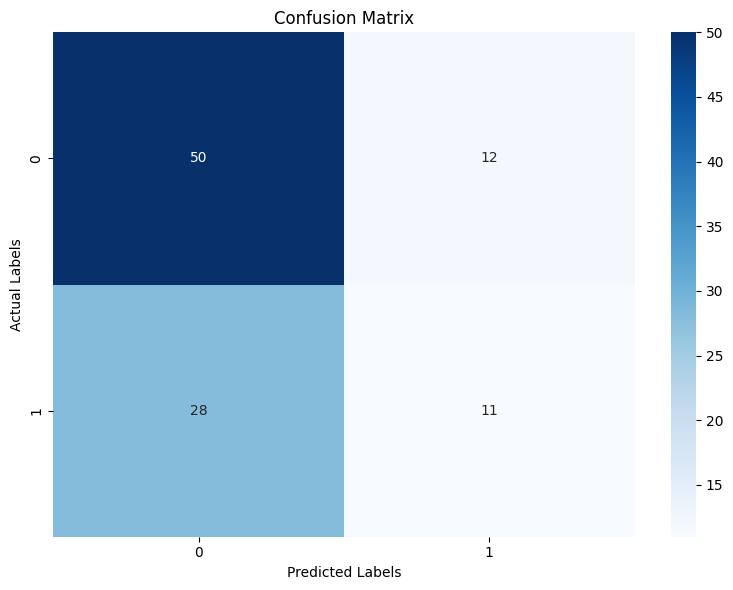

In [9]:
import pandas as pd
import numpy as np
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import cross_val_score, GridSearchCV

# Load data
train_df = pd.read_csv('cleaned_training.csv')
test_df = pd.read_csv('cleandata-join.csv')

# Text cleaning
def basic_cleaning(text):
    text = text.strip()
    text = text.lower()
    return text

train_df['text'] = train_df['text'].apply(basic_cleaning)
test_df['text'] = test_df['text'].apply(basic_cleaning)

# Extract features and labels
X_train = train_df['text']
y_train = train_df['Label']
X_test = test_df['text']
y_test = test_df['Label']

# Create the model
pipeline = make_pipeline(
    TfidfVectorizer(),
    LinearSVC()
)

# Perform simple cross-validation
print("Performing 5-fold cross-validation...")
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1_weighted')
print(f"Cross-validation F1 scores: {cv_scores}")
print(f"Average F1 score: {cv_scores.mean():.4f}")

# Perform simple parameter optimization
print("Performing parameter optimization...")
param_grid = {
    'tfidfvectorizer__max_features': [5000, 10000,15000,20000],
    'linearsvc__C': [0.1, 1, 10]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=3,  # Reduce to 3-fold for faster processing
    scoring='f1_weighted'
)

grid_search.fit(X_train, y_train)

# Output best parameters
print("\nBest parameters:")
print(grid_search.best_params_)
print(f"Best cross-validation F1 score: {grid_search.best_score_:.4f}")

# Use the best model to make predictions
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Evaluation metrics
print('\nEvaluation on the test set:')
print('Accuracy:', accuracy_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred, average='weighted'))
print('Classification Report:\n', classification_report(y_test, y_pred))

# Visualize confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.tight_layout()
plt.show()


In [48]:
results_df = pd.DataFrame({
    'Text': X_test,
    'True Label': y_test,
    'Predicted Label': y_pred
})

incorrect_predictions = results_df[results_df['True Label'] != results_df['Predicted Label']]

print("\nNumber of misclassified samples:", len(incorrect_predictions))
print("\nMisclassified samples:")
print(incorrect_predictions)

# Save misclassified samples to a CSV file
incorrect_predictions.to_csv('incorrect_predictions_svm2.csv', index=False)



Number of misclassified samples: 40

Misclassified samples:
                                                  Text  True Label  \
2     i'm on to you. you're a faker. you aren't dying.           1   
3                                                what?           1   
4    okay, in the sylvia plath philosophy way, we'r...           1   
6    you're a tourist. i saw you at melanoma, tuber...           1   
8                                     practicing what?           1   
9    telling me off. is it going as well as you hop...           1   
24             look, i can't cry with a faker present.           1   
28   i think it's too late for changes, michael. i ...           1   
30   tell me, michael. what really happened with pe...           1   
32   i didn't even know he had a brother. and where...           1   
34    and that's all he had to do. just show his face.           1   
36                  you would have killed his brother?           1   
39   i'll bring the children 

# Bert

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epoch 1/10 (Validation): 100%|██████████| 7/7 [00:00<00:00, 31.47it/s]


Epoch 1:
Training Loss: 0.6605
Validation Accuracy: 0.7619
Validation F1 Score: 0.6589
Saved new best model


Epoch 2/10 (Validation): 100%|██████████| 7/7 [00:00<00:00, 30.31it/s]


Epoch 2:
Training Loss: 0.5789
Validation Accuracy: 0.7714
Validation F1 Score: 0.6808
Saved new best model


Epoch 3/10 (Validation): 100%|██████████| 7/7 [00:00<00:00, 30.25it/s]


...

Epoch 9:
Training Loss: 0.0087
Validation Accuracy: 0.8571
Validation F1 Score: 0.8485
Saved new best model


Epoch 10/10 (Validation): 100%|██████████| 7/7 [00:00<00:00, 30.05it/s]
/tmp/ipykernel_796/3329584575.py:124: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_

Epoch 10:
Training Loss: 0.0071
Validation Accuracy: 0.8476
Validation F1 Score: 0.8400


Final Evaluation: 100%|██████████| 7/7 [00:00<00:00, 12.38it/s]



Final Test Set Results:
Accuracy: 0.7425742574257426
F1 Score: 0.7274761443535659
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.90      0.81        62
           1       0.76      0.49      0.59        39

    accuracy                           0.74       101
   macro avg       0.75      0.70      0.70       101
weighted avg       0.75      0.74      0.73       101

Confusion Matrix: 
 [[56  6]
 [20 19]]


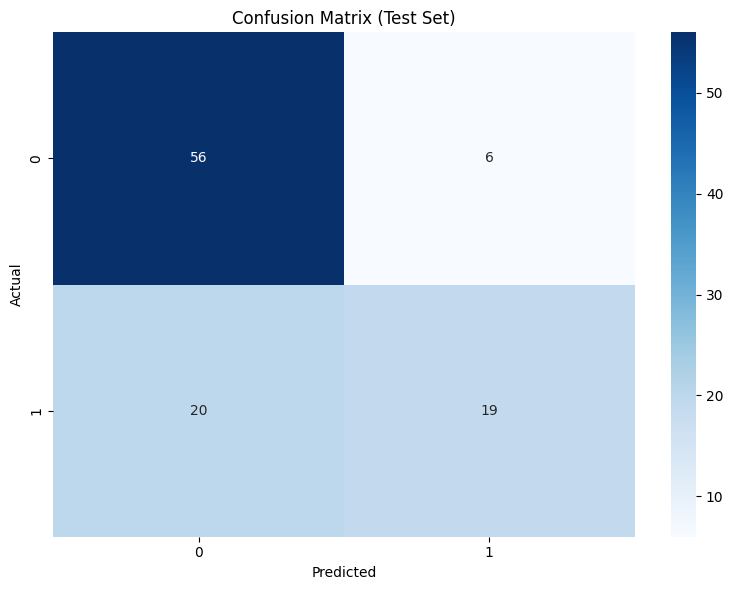


Misclassified Texts:
Total misclassified: 26
Saved to misclassified_texts.csv

Sample Misclassified Texts:
                                                text  true_label  \
2   i'm on to you. you're a faker. you aren't dying.           1   
4  okay, in the sylvia plath philosophy way, we'r...           1   
6  you're a tourist. i saw you at melanoma, tuber...           1   
7                   and i saw you practicing this...           1   
9  telling me off. is it going as well as you hop...           1   

   predicted_label  
2                0  
4                0  
6                0  
7                0  
9                0  


In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import re

# Load data
train_df = pd.read_csv('cleaned_training.csv')
val_df = pd.read_csv('cleaned_validation.csv')
test_df = pd.read_csv('cleaned_testing.csv')

# Basic text cleaning function
def basic_cleaning(text):
    # Remove extra whitespace from text
    text = text.strip()
    # Convert to lowercase
    text = text.lower()
    return text

# Apply basic cleaning to the text data
train_df['text'] = train_df['text'].apply(basic_cleaning)
val_df['text'] = val_df['text'].apply(basic_cleaning)
test_df['text'] = test_df['text'].apply(basic_cleaning)

# Prepare data
X_train = train_df['text'].tolist()
y_train = train_df['Label'].tolist()
X_val = val_df['text'].tolist()
y_val = val_df['Label'].tolist()
X_test = test_df['text'].tolist()
y_test = test_df['Label'].tolist()

# Initialize BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
num_labels = len(set(y_train))
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)

# Tokenize data
def tokenize_data(texts, labels):
    encodings = tokenizer(texts, truncation=True, padding=True, max_length=128, return_tensors='pt')
    input_ids = encodings['input_ids']
    attention_mask = encodings['attention_mask']
    labels = torch.tensor(labels)
    return input_ids, attention_mask, labels

# Prepare data for training and evaluation
train_input_ids, train_attention_mask, train_labels = tokenize_data(X_train, y_train)
val_input_ids, val_attention_mask, val_labels = tokenize_data(X_val, y_val)
test_input_ids, test_attention_mask, test_labels = tokenize_data(X_test, y_test)

# Create DataLoaders
batch_size = 16
train_dataset = TensorDataset(train_input_ids, train_attention_mask, train_labels)
val_dataset = TensorDataset(val_input_ids, val_attention_mask, val_labels)
test_dataset = TensorDataset(test_input_ids, test_attention_mask, test_labels)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# Setup training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
epochs = 10

# Training and validation loop
best_val_f1 = 0
for epoch in range(epochs):
    # Training phase
    model.train()
    total_train_loss = 0
    for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} (Training)'):
        batch_input_ids, batch_attention_mask, batch_labels = [b.to(device) for b in batch]
        
        optimizer.zero_grad()
        outputs = model(input_ids=batch_input_ids, 
                        attention_mask=batch_attention_mask, 
                        labels=batch_labels)
        
        loss = outputs.loss
        total_train_loss += loss.item()
        
        loss.backward()
        optimizer.step()
    
    # Validation phase
    model.eval()
    val_preds = []
    val_true = []
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs} (Validation)'):
            batch_input_ids, batch_attention_mask, batch_labels = [b.to(device) for b in batch]
            
            outputs = model(input_ids=batch_input_ids, 
                            attention_mask=batch_attention_mask)
            
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=-1).cpu().numpy()
            val_preds.extend(predictions)
            val_true.extend(batch_labels.cpu().numpy())
    
    # Calculate validation metrics
    val_accuracy = accuracy_score(val_true, val_preds)
    val_f1 = f1_score(val_true, val_preds, average='weighted')
    
    print(f'Epoch {epoch+1}:')
    print(f'Training Loss: {total_train_loss/len(train_loader):.4f}')
    print(f'Validation Accuracy: {val_accuracy:.4f}')
    print(f'Validation F1 Score: {val_f1:.4f}')
    
    # Save the best model based on validation F1 score
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'best_model.pth')
        print("Saved new best model")

# Load the best model
model.load_state_dict(torch.load('best_model.pth'))

# Final evaluation on test set
model.eval()
all_preds = []
all_true = []
with torch.no_grad():
    for batch in tqdm(test_loader, desc='Final Evaluation'):
        batch_input_ids, batch_attention_mask, batch_labels = [b.to(device) for b in batch]
        
        outputs = model(input_ids=batch_input_ids, 
                        attention_mask=batch_attention_mask)
        
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=-1).cpu().numpy()
        all_preds.extend(predictions)
        all_true.extend(batch_labels.cpu().numpy())

# Calculate metrics
accuracy = accuracy_score(all_true, all_preds)
f1 = f1_score(all_true, all_preds, average='weighted')

print('\nFinal Test Set Results:')
print('Accuracy:', accuracy)
print('F1 Score:', f1)
print('Classification Report:\n', classification_report(all_true, all_preds))
print('Confusion Matrix: \n', confusion_matrix(all_true, all_preds))

# Plot Confusion Matrix
cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(all_true), 
            yticklabels=np.unique(all_true))
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Export misclassified texts to CSV
misclassified_df = pd.DataFrame({
    'text': X_test,  # Using the original test texts
    'true_label': all_true,
    'predicted_label': all_preds
})

# Filter to keep only misclassified samples
misclassified_df = misclassified_df[misclassified_df['true_label'] != misclassified_df['predicted_label']]

# Save misclassified texts to a CSV
misclassified_df.to_csv('misclassified_texts.csv', index=False)

print(f'\nMisclassified Texts:')
print(f'Total misclassified: {len(misclassified_df)}')
print(f'Saved to misclassified_texts.csv')

# Optional: Display first few misclassified texts
print('\nSample Misclassified Texts:')
print(misclassified_df.head())

# Machine learning overview

In [25]:
import pandas as pd
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import re

# Load data
train_df = pd.read_csv('cleaned_training.csv')
test_df = pd.read_csv('cleaned_testing.csv')
val_df = pd.read_csv('cleaned_validation.csv')

# Basic text cleaning function
def basic_cleaning(text):
    # Remove extra whitespace from text
    text = text.strip()
    # Convert to lowercase
    text = text.lower()
    # Remove non-alphanumeric characters (optional: adjust according to task requirements)
    #text = re.sub(r'[^a-z\s]', '', text)
    return text

# Clean the text data in the training, test, and validation datasets
train_df['text'] = train_df['text'].apply(basic_cleaning)
test_df['text'] = test_df['text'].apply(basic_cleaning)
val_df['text'] = val_df['text'].apply(basic_cleaning)

# Prepare datasets
X_train = train_df['text']
y_train = train_df['Label']
X_test = test_df['text']
y_test = test_df['Label']
X_val = val_df['text']
y_val = val_df['Label']

# Define all classifiers to test within a pipeline
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM (Linear)': SVC(kernel='linear'),
    'SVM (RBF)': SVC(kernel='rbf'),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'KNN': KNeighborsClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'XGBoost': xgb.XGBClassifier(),
    'LightGBM': lgb.LGBMClassifier(
        min_child_samples=5, 
        min_child_weight=0.001,
        min_split_gain=0.0,
        verbose=0
    ),
    'CatBoost': CatBoostClassifier(verbose=0),
    'AdaBoost': AdaBoostClassifier(),
    'Multinomial NB': MultinomialNB(),
    'Bernoulli NB': BernoulliNB(),
    'Complement NB': ComplementNB()
}

# Store results for comparison
results = {}

# Test each classifier
for name, clf in classifiers.items():
    print(f"\n--- {name} ---")
    
    # Create the pipeline with TF-IDF vectorizer
    pipeline = make_pipeline(
        TfidfVectorizer(),
        clf
    )
    
    # Train the model on training data
    pipeline.fit(X_train, y_train)
    
    # Evaluate on test set
    y_test_pred = pipeline.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    
    # Evaluate on validation set
    y_val_pred = pipeline.predict(X_val)
    val_accuracy = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')
    
    print('Test Set Results:')
    print(f'Accuracy: {test_accuracy:.4f}')
    print(f'F1 Score: {test_f1:.4f}')
    print('Confusion Matrix:\n', confusion_matrix(y_test, y_test_pred))
    print('Classification Report:\n', classification_report(y_test, y_test_pred))
    
    print('\nValidation Set Results:')
    print(f'Accuracy: {val_accuracy:.4f}')
    print(f'F1 Score: {val_f1:.4f}')
    print('Confusion Matrix:\n', confusion_matrix(y_val, y_val_pred))
    print('Classification Report:\n', classification_report(y_val, y_val_pred))
    
    # Perform cross-validation
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5)
    
    # Store results for comparison
    results[name] = {
        'test_accuracy': test_accuracy,
        'test_f1': test_f1,
        'val_accuracy': val_accuracy,
        'val_f1': val_f1,
        'cv_mean_score': cv_scores.mean(),
        'cv_std_score': cv_scores.std()
    }

# Compare all models and show the results in a table
print("\n--- Summary of Results ---")
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('val_f1', ascending=False)
print(results_df)

# Optional: Save results to CSV
#results_df.to_csv('model_comparison_results.csv')




--- Logistic Regression ---
Test Set Results:
Accuracy: 0.6139
F1 Score: 0.5251
Confusion Matrix:
 [[58  4]
 [35  4]]
Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.94      0.75        62
           1       0.50      0.10      0.17        39

    accuracy                           0.61       101
   macro avg       0.56      0.52      0.46       101
weighted avg       0.58      0.61      0.53       101


Validation Set Results:
Accuracy: 0.7429
F1 Score: 0.6890
Confusion Matrix:
 [[75  5]
 [22  3]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.94      0.85        80
           1       0.38      0.12      0.18        25

    accuracy                           0.74       105
   macro avg       0.57      0.53      0.51       105
weighted avg       0.68      0.74      0.69       105


--- SVM (Linear) ---
Test Set Results:
Accuracy: 0.5743
F1 Score: 0.5465
Confusio

/home/x/anaconda3/envs/nlp_env/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/x/anaconda3/envs/nlp_env/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/x/anaconda3/envs/nlp_env/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/x/anaconda3/envs/nlp_env/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME alg


--- Multinomial NB ---
Test Set Results:
Accuracy: 0.6139
F1 Score: 0.4670
Confusion Matrix:
 [[62  0]
 [39  0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.61      1.00      0.76        62
           1       0.00      0.00      0.00        39

    accuracy                           0.61       101
   macro avg       0.31      0.50      0.38       101
weighted avg       0.38      0.61      0.47       101


Validation Set Results:
Accuracy: 0.7619
F1 Score: 0.6755
Confusion Matrix:
 [[79  1]
 [24  1]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.99      0.86        80
           1       0.50      0.04      0.07        25

    accuracy                           0.76       105
   macro avg       0.63      0.51      0.47       105
weighted avg       0.70      0.76      0.68       105


--- Bernoulli NB ---
Test Set Results:
Accuracy: 0.6634
F1 Score: 0.5910
Confusion Mat

/home/x/anaconda3/envs/nlp_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
